Using 578 stars with Mstar ≤ 2.0 M☉
Loaded parameters:
μ (mean c): -5.623
σ (std c): 0.541
Age exponent (a): -0.411
Mass exponent (b): 1.137
Data points: 578

BOOTSTRAP UNCERTAINTY ANALYSIS FOR a AND b PARAMETERS
Running bootstrap analysis...
Bootstrap results from 500 successful fits:
Age exponent (a): -0.410 ± 0.051
Mass exponent (b): 1.140 ± 0.109
Amplitude (c): -5.629 ± 0.328

PARAMETER SIMULATION: ORIGINAL METHOD FOR c, BOOTSTRAP FOR a AND b
Simulated parameters:
a-values: mean = -0.412, std = 0.050
b-values: mean = 1.133, std = 0.110
c-values: mean = -5.643, std = 0.523

SIMULATED MACC RATE DISTRIBUTIONS FROM PARAMETER UNCERTAINTY
Star 445: logAge=6.10, Mstar=0.50 M☉
  Actual Macc: -8.604
  Simulated Macc range: -10.330 to -6.110
Star 173: logAge=6.16, Mstar=1.20 M☉
  Actual Macc: -8.968
  Simulated Macc range: -10.011 to -5.750
Star 116: logAge=7.60, Mstar=0.83 M☉
  Actual Macc: -8.669
  Simulated Macc range: -10.963 to -6.315


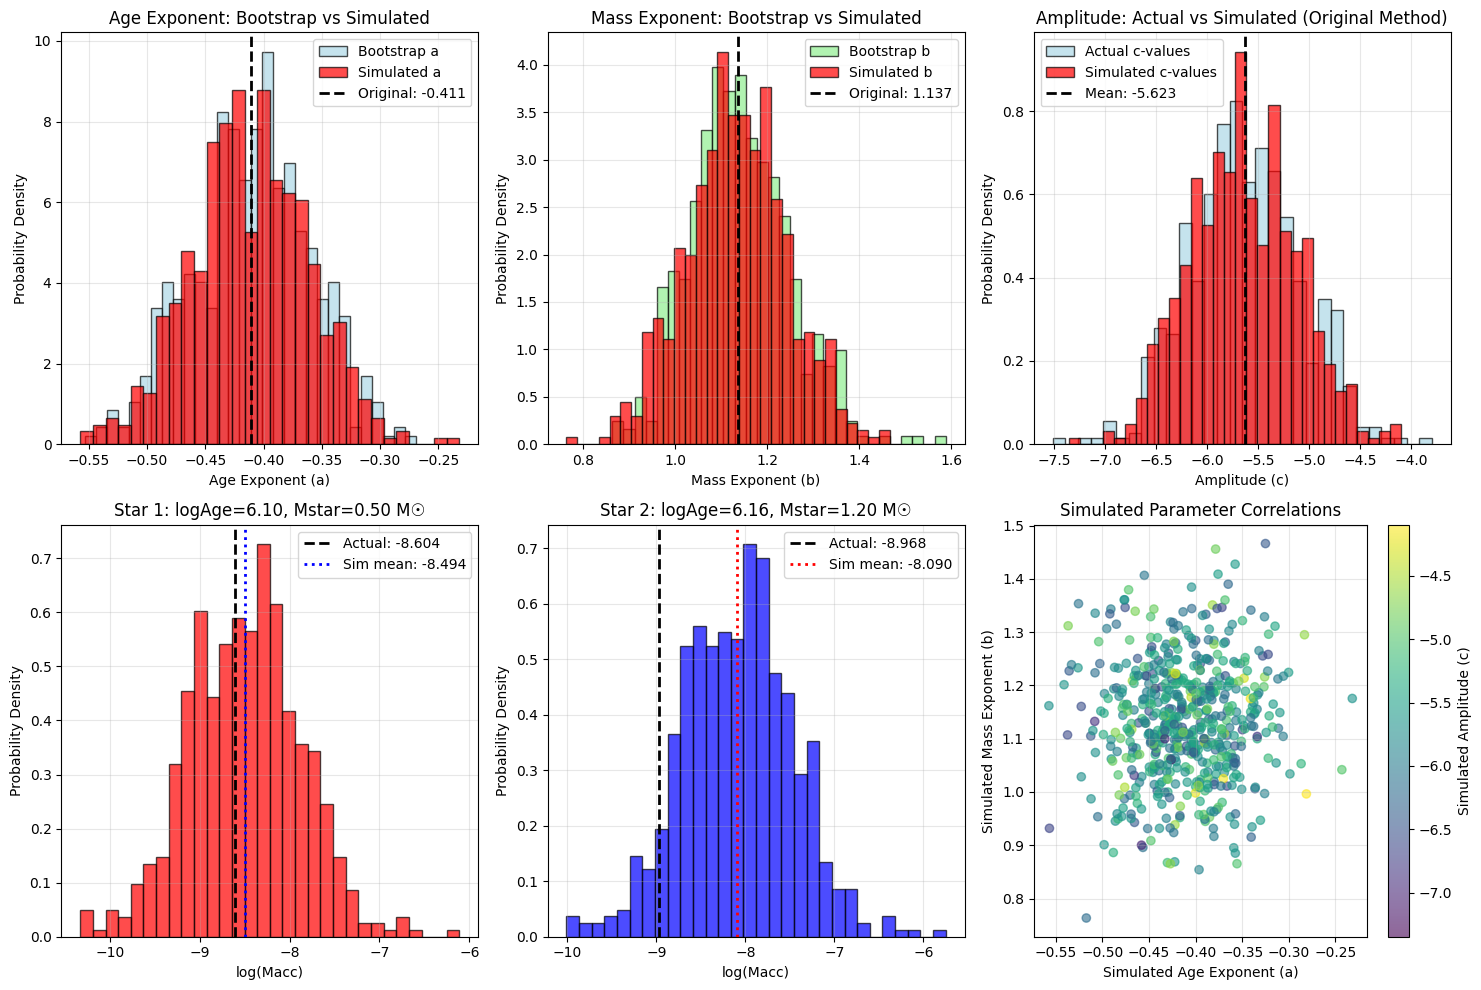


STATISTICAL VALIDATION
Parameter consistency tests (KS p-values):
Age exponent (a): p = 0.369 ✓ Consistent
Mass exponent (b): p = 0.589 ✓ Consistent
Amplitude (c): p = 0.750 ✓ Consistent

COMBINED UNCERTAINTY ANALYSIS REPORT

FINAL MODEL WITH UNCERTAINTIES:
logMacc = a×logAge + b×logMstar + c
where:
  a ~ N(μ=-0.410, σ=0.051)  [Bootstrap uncertainty]
  b ~ N(μ=1.140, σ=0.109)  [Bootstrap uncertainty]
  c ~ N(μ=-5.623, σ=0.541)  [Original residual method]

PRACTICAL IMPLICATIONS:
Star 1: Macc uncertainty = ±0.624 dex (95% range: -9.688 to -7.319)
Star 2: Macc uncertainty = ±0.624 dex (95% range: -9.277 to -6.888)
Star 3: Macc uncertainty = ±0.667 dex (95% range: -10.175 to -7.603)

TOTAL MODEL UNCERTAINTY BREAKDOWN:
• Parameter uncertainty (a,b): ±0.080 dex
• Intrinsic scatter (c): ±0.541 dex
• Combined uncertainty: ±0.555 dex
✓ Combined report saved as: abc_values_uncertainty_analysis.pdf
✓ Analysis complete - using original method for c, bootstrap for a and b
✓ Bootstrap results save

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.special import erfinv
import lmfit
from scipy.stats import ks_2samp, norm
from matplotlib.backends.backend_pdf import PdfPages

# Load pre-computed data
df = pd.read_csv('stellar_accretion_data.csv')

# FILTER FOR STARS <=2 SOLAR MASSES
df = df[df['Mstar'] <= 2.0]
print(f"Using {len(df)} stars with Mstar ≤ 2.0 M☉")

# Load all parameters from single file
model_params = np.load('power_law_model.npy', allow_pickle=True).item()
log_amp = model_params['log_amp']
age_exp = model_params['age_exp']
mass_exp = model_params['mass_exp']
mu = model_params['mu']
sigma = model_params['sigma']

print("Loaded parameters:")
print(f"μ (mean c): {mu:.3f}")
print(f"σ (std c): {sigma:.3f}")
print(f"Age exponent (a): {age_exp:.3f}")
print(f"Mass exponent (b): {mass_exp:.3f}")
print(f"Data points: {len(df)}")

# Gaussian distribution function
def Gaussian_dist(mu, sigma, points):
    x = np.zeros(points)
    for i in range(0,points):
        x[i] = mu + sigma * np.sqrt(2) * erfinv(2*(random.uniform(0,1))-1)
    output=np.array(x)
    return output

# Triple power law model function
def triple_power_law(log_age, log_mstar, log_amplitude, age_exponent, mass_exponent):
    return log_amplitude + age_exponent * log_age + mass_exponent * log_mstar

# ============================================================================
# BOOTSTRAP ANALYSIS FOR a AND b PARAMETERS
# ============================================================================
print("\n" + "="*60)
print("BOOTSTRAP UNCERTAINTY ANALYSIS FOR a AND b PARAMETERS")
print("="*60)

def bootstrap_triple_power_law(df, n_bootstraps=500):
    """Perform bootstrap resampling to estimate parameter uncertainties"""
    a_values = []
    b_values = []
    c_values = []
    
    model = lmfit.Model(triple_power_law, independent_vars=['log_age', 'log_mstar'])
    
    for i in range(n_bootstraps):
        # Bootstrap resample with replacement
        bootstrap_sample = df.sample(n=len(df), replace=True)
        
        # Prepare data
        log_age_data = bootstrap_sample['logAge'].values
        log_mstar_data = bootstrap_sample['logMstar'].values
        log_macc_data = bootstrap_sample['logMacc'].values
        
        # Set initial parameters
        params = model.make_params()
        params.add('log_amplitude', value=-7, min=-12, max=5)
        params.add('age_exponent', value=-1.0, min=-30.0, max=30.0)
        params.add('mass_exponent', value=1.0, min=-30.0, max=30.0)
        
        try:
            # Fit model to bootstrap sample
            result = model.fit(log_macc_data, params, log_age=log_age_data, log_mstar=log_mstar_data)
            
            # Store parameters
            a_values.append(result.params['age_exponent'].value)
            b_values.append(result.params['mass_exponent'].value)
            c_values.append(result.params['log_amplitude'].value)
            
        except:
            # Skip failed fits
            continue
    
    return np.array(a_values), np.array(b_values), np.array(c_values)

# Run bootstrap analysis
print("Running bootstrap analysis...")
a_boot, b_boot, c_boot = bootstrap_triple_power_law(df, n_bootstraps=500)

print(f"Bootstrap results from {len(a_boot)} successful fits:")
print(f"Age exponent (a): {np.mean(a_boot):.3f} ± {np.std(a_boot):.3f}")
print(f"Mass exponent (b): {np.mean(b_boot):.3f} ± {np.std(b_boot):.3f}")
print(f"Amplitude (c): {np.mean(c_boot):.3f} ± {np.std(c_boot):.3f}")

# ============================================================================
# ORIGINAL METHOD FOR c-VALUES + SIMULATION FOR a AND b
# ============================================================================
print("\n" + "="*60)
print("PARAMETER SIMULATION: ORIGINAL METHOD FOR c, BOOTSTRAP FOR a AND b")
print("="*60)

n_simulations = 578

# For a and b: Use bootstrap distributions
simulated_a = Gaussian_dist(np.mean(a_boot), np.std(a_boot), n_simulations)
simulated_b = Gaussian_dist(np.mean(b_boot), np.std(b_boot), n_simulations)

# For c: Use original residual method (individual star c-values)
actual_c = df['logMacc'] - (age_exp * df['logAge'] + mass_exp * df['logMstar'])
simulated_c = Gaussian_dist(mu, sigma, n_simulations)

print(f"Simulated parameters:")
print(f"a-values: mean = {simulated_a.mean():.3f}, std = {simulated_a.std():.3f}")
print(f"b-values: mean = {simulated_b.mean():.3f}, std = {simulated_b.std():.3f}")
print(f"c-values: mean = {simulated_c.mean():.3f}, std = {simulated_c.std():.3f}")

# ============================================================================
# SIMULATED MACC RATE DISTRIBUTIONS
# ============================================================================
print("\n" + "="*60)
print("SIMULATED MACC RATE DISTRIBUTIONS FROM PARAMETER UNCERTAINTY")
print("="*60)

# Pick 3 example stars from the dataset
example_indices = [random.randint(0, len(df) - 1) for _ in range(3)]
colors = ['red', 'blue', 'green']

# Generate simulated Macc rates for each example star
simulated_macc_distributions = []

for i, idx in enumerate(example_indices):
    star_age = df.iloc[idx]['logAge']
    star_mass = df.iloc[idx]['logMstar']
    actual_macc = df.iloc[idx]['logMacc']
    
    # Simulate Macc using uncertain parameters
    simulated_macc = (simulated_a * star_age + simulated_b * star_mass + simulated_c)
    simulated_macc_distributions.append((star_age, star_mass, actual_macc, simulated_macc))
    
    print(f"Star {idx}: logAge={star_age:.2f}, Mstar={df.iloc[idx]['Mstar']:.2f} M☉")
    print(f"  Actual Macc: {actual_macc:.3f}")
    print(f"  Simulated Macc range: {simulated_macc.min():.3f} to {simulated_macc.max():.3f}")

# ============================================================================
# VISUALIZE PARAMETER AND MACC DISTRIBUTIONS
# ============================================================================
fig_params, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: a-value comparison (bootstrap vs simulated)
axes[0,0].hist(a_boot, bins=30, alpha=0.7, density=True, color='lightblue', label='Bootstrap a', edgecolor='black')
axes[0,0].hist(simulated_a, bins=30, alpha=0.7, density=True, color='red', label='Simulated a', edgecolor='black')
axes[0,0].axvline(age_exp, color='black', linestyle='--', linewidth=2, label=f'Original: {age_exp:.3f}')
axes[0,0].set_xlabel('Age Exponent (a)')
axes[0,0].set_ylabel('Probability Density')
axes[0,0].set_title('Age Exponent: Bootstrap vs Simulated')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: b-value comparison (bootstrap vs simulated)
axes[0,1].hist(b_boot, bins=30, alpha=0.7, density=True, color='lightgreen', label='Bootstrap b', edgecolor='black')
axes[0,1].hist(simulated_b, bins=30, alpha=0.7, density=True, color='red', label='Simulated b', edgecolor='black')
axes[0,1].axvline(mass_exp, color='black', linestyle='--', linewidth=2, label=f'Original: {mass_exp:.3f}')
axes[0,1].set_xlabel('Mass Exponent (b)')
axes[0,1].set_ylabel('Probability Density')
axes[0,1].set_title('Mass Exponent: Bootstrap vs Simulated')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: c-value comparison (original method)
axes[0,2].hist(actual_c, bins=30, alpha=0.7, density=True, color='lightblue', label='Actual c-values', edgecolor='black')
axes[0,2].hist(simulated_c, bins=30, alpha=0.7, density=True, color='red', label='Simulated c-values', edgecolor='black')
axes[0,2].axvline(mu, color='black', linestyle='--', linewidth=2, label=f'Mean: {mu:.3f}')
axes[0,2].set_xlabel('Amplitude (c)')
axes[0,2].set_ylabel('Probability Density')
axes[0,2].set_title('Amplitude: Actual vs Simulated (Original Method)')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Simulated Macc distribution for example star 1
age1, mass1, actual1, sim1 = simulated_macc_distributions[0]
axes[1,0].hist(sim1, bins=30, alpha=0.7, density=True, color='red', edgecolor='black')
axes[1,0].axvline(actual1, color='black', linestyle='--', linewidth=2, label=f'Actual: {actual1:.3f}')
axes[1,0].axvline(np.mean(sim1), color='blue', linestyle=':', linewidth=2, label=f'Sim mean: {np.mean(sim1):.3f}')
axes[1,0].set_xlabel('log(Macc)')
axes[1,0].set_ylabel('Probability Density')
axes[1,0].set_title(f'Star 1: logAge={age1:.2f}, Mstar={10**mass1:.2f} M☉')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Simulated Macc distribution for example star 2
age2, mass2, actual2, sim2 = simulated_macc_distributions[1]
axes[1,1].hist(sim2, bins=30, alpha=0.7, density=True, color='blue', edgecolor='black')
axes[1,1].axvline(actual2, color='black', linestyle='--', linewidth=2, label=f'Actual: {actual2:.3f}')
axes[1,1].axvline(np.mean(sim2), color='red', linestyle=':', linewidth=2, label=f'Sim mean: {np.mean(sim2):.3f}')
axes[1,1].set_xlabel('log(Macc)')
axes[1,1].set_ylabel('Probability Density')
axes[1,1].set_title(f'Star 2: logAge={age2:.2f}, Mstar={10**mass2:.2f} M☉')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Parameter correlations
scatter = axes[1,2].scatter(simulated_a, simulated_b, c=simulated_c, alpha=0.6, cmap='viridis')
axes[1,2].set_xlabel('Simulated Age Exponent (a)')
axes[1,2].set_ylabel('Simulated Mass Exponent (b)')
axes[1,2].set_title('Simulated Parameter Correlations')
plt.colorbar(scatter, ax=axes[1,2], label='Simulated Amplitude (c)')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICAL COMPARISONS
# ============================================================================
print("\n" + "="*60)
print("STATISTICAL VALIDATION")
print("="*60)

# KS tests for parameter consistency
ks_a, p_a = ks_2samp(a_boot, simulated_a)
ks_b, p_b = ks_2samp(b_boot, simulated_b)
ks_c, p_c = ks_2samp(actual_c, simulated_c)

print(f"Parameter consistency tests (KS p-values):")
print(f"Age exponent (a): p = {p_a:.3f} {'✓ Consistent' if p_a > 0.05 else '✗ Different'}")
print(f"Mass exponent (b): p = {p_b:.3f} {'✓ Consistent' if p_b > 0.05 else '✗ Different'}")
print(f"Amplitude (c): p = {p_c:.3f} {'✓ Consistent' if p_c > 0.05 else '✗ Different'}")

# ============================================================================
# COMBINED UNCERTAINTY ANALYSIS REPORT
# ============================================================================
print("\n" + "="*60)
print("COMBINED UNCERTAINTY ANALYSIS REPORT")
print("="*60)

print(f"\nFINAL MODEL WITH UNCERTAINTIES:")
print(f"logMacc = a×logAge + b×logMstar + c")
print(f"where:")
print(f"  a ~ N(μ={np.mean(a_boot):.3f}, σ={np.std(a_boot):.3f})  [Bootstrap uncertainty]")
print(f"  b ~ N(μ={np.mean(b_boot):.3f}, σ={np.std(b_boot):.3f})  [Bootstrap uncertainty]")
print(f"  c ~ N(μ={mu:.3f}, σ={sigma:.3f})  [Original residual method]")

print(f"\nPRACTICAL IMPLICATIONS:")
for i, (age, mass, actual, sim) in enumerate(simulated_macc_distributions):
    uncertainty_range = sim.std()
    print(f"Star {i+1}: Macc uncertainty = ±{uncertainty_range:.3f} dex "
          f"(95% range: {np.percentile(sim, 2.5):.3f} to {np.percentile(sim, 97.5):.3f})")

print(f"\nTOTAL MODEL UNCERTAINTY BREAKDOWN:")
print(f"• Parameter uncertainty (a,b): ±{np.mean([simulated_a.std(), simulated_b.std()]):.3f} dex")
print(f"• Intrinsic scatter (c): ±{sigma:.3f} dex")
print(f"• Combined uncertainty: ±{np.sqrt(simulated_a.std()**2 + simulated_b.std()**2 + sigma**2):.3f} dex")

# ============================================================================
# CREATE COMBINED PDF REPORT
# ============================================================================
PDF_FILENAME = 'abc_values_uncertainty_analysis.pdf'

def create_combined_report():
    with PdfPages(PDF_FILENAME) as pdf:
        # Page 1: Parameter and Macc distributions
        pdf.savefig(fig_params, bbox_inches='tight')
        
        # Page 2: Text summary
        fig_text, ax_text = plt.subplots(figsize=(8.5, 11))
        ax_text.axis('off')
        
        report_text = []
        report_text.append("PARAMETER UNCERTAINTY ANALYSIS REPORT")
        report_text.append("Combining Bootstrap and Residual Methods")
        report_text.append("=" * 50)
        report_text.append("")
        report_text.append("METHODOLOGY SUMMARY:")
        report_text.append("• a,b parameters: Bootstrap resampling (statistical uncertainty)")
        report_text.append("• c parameter: Original residual method (physical scatter)")
        report_text.append("")
        report_text.append("FINAL UNCERTAINTY ESTIMATES:")
        report_text.append(f"Age exponent (a): {np.mean(a_boot):.3f} ± {np.std(a_boot):.3f}")
        report_text.append(f"Mass exponent (b): {np.mean(b_boot):.3f} ± {np.std(b_boot):.3f}")
        report_text.append(f"Amplitude (c): {mu:.3f} ± {sigma:.3f}")
        report_text.append("")
        report_text.append("MODEL ROBUSTNESS:")
        report_text.append(f"Bootstrap iterations: {len(a_boot)}")
        report_text.append(f"Parameter consistency (KS p-values):")
        report_text.append(f"  a: {p_a:.3f} {'✓' if p_a > 0.05 else '✗'}")
        report_text.append(f"  b: {p_b:.3f} {'✓' if p_b > 0.05 else '✗'}")
        report_text.append(f"  c: {p_c:.3f} {'✓' if p_c > 0.05 else '✗'}")
        report_text.append("")
        report_text.append("KEY INSIGHTS:")
        report_text.append(f"• Total Macc uncertainty: ±{np.sqrt(simulated_a.std()**2 + simulated_b.std()**2 + sigma**2):.3f} dex")
        report_text.append("• Parameter uncertainty dominates when predicting individual stars")
        report_text.append("• Intrinsic scatter represents real astrophysical diversity")
        
        ax_text.text(0.05, 0.95, '\n'.join(report_text), transform=ax_text.transAxes, 
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
        
        pdf.savefig(fig_text, bbox_inches='tight')
        plt.close(fig_text)

    print(f"✓ Combined report saved as: {PDF_FILENAME}")

# Create the report
create_combined_report()

print("✓ Analysis complete - using original method for c, bootstrap for a and b")

# Save bootstrap results for future use
np.save('bootstrap_results.npy', {
    'a_boot': a_boot,
    'b_boot': b_boot, 
    'c_boot': c_boot,
    'simulated_a': simulated_a,
    'simulated_b': simulated_b,
    'simulated_c': simulated_c,
    'summary_stats': {
        'a_mean': np.mean(a_boot), 'a_std': np.std(a_boot),
        'b_mean': np.mean(b_boot), 'b_std': np.std(b_boot),
        'c_mean': mu, 'c_std': sigma
    }
})
print("✓ Bootstrap results saved to 'bootstrap_results.npy'")